In [1]:
!pip install -q xgboost kaggle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Libraries loaded.')

Libraries loaded.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving application_train.csv to application_train (1).csv


In [4]:
df = pd.read_csv('application_train.csv')
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:\n{df["TARGET"].value_counts(normalize=True).round(4)}')
df.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique()
})
print(f'Numerical features: {df.select_dtypes(include=np.number).shape[1]}')
print(f'Categorical features: {df.select_dtypes(include="object").shape[1]}')
print(f'\nFeatures with >40% missing:')
info_df[info_df['missing_pct'] > 40].sort_values('missing_pct', ascending=False)

Numerical features: 106
Categorical features: 16

Features with >40% missing:


,dtype,missing,missing_pct,nunique
COMMONAREA_AVG,float64,214865,69.87,3181
COMMONAREA_MEDI,float64,214865,69.87,3202
COMMONAREA_MODE,float64,214865,69.87,3128
NONLIVINGAPARTMENTS_AVG,float64,213514,69.43,386
NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43,214
NONLIVINGAPARTMENTS_MODE,float64,213514,69.43,167
FONDKAPREMONT_MODE,object,210295,68.39,4
LIVINGAPARTMENTS_MEDI,float64,210199,68.35,1097
LIVINGAPARTMENTS_AVG,float64,210199,68.35,1868
LIVINGAPARTMENTS_MODE,float64,210199,68.35,736


In [7]:
high_missing_cols = info_df[info_df['missing_pct'] > 40].index.tolist()
print(f'Dropping {len(high_missing_cols)} columns with >40% missing: {high_missing_cols}')
df.drop(columns=high_missing_cols, inplace=True, errors='ignore')
df.drop(columns=['SK_ID_CURR'], inplace=True, errors='ignore')

y = df['TARGET']
X = df.drop(columns=['TARGET'])

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'\nRemaining shape: {X.shape}')
print(f'Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}')


Dropping 49 columns with >40% missing: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WA

KeyError: "['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENC

In [8]:
df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
from sklearn.model_selection import train_test_split

# Split BEFORE any imputation/encoding to prevent data leakage
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} ({y_train.mean():.4f} default rate)')
print(f'Val:   {X_val.shape[0]} ({y_val.mean():.4f} default rate)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.4f} default rate)')

Train: 215257 (0.0807 default rate)
Val:   46127 (0.0807 default rate)
Test:  46127 (0.0807 default rate)


In [11]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print(f'Missing after imputation — Train: {X_train.isnull().sum().sum()}, Val: {X_val.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}')

Missing after imputation — Train: 0, Val: 0, Test: 0


In [13]:
from sklearn.preprocessing import LabelEncoder

binary_cats = [c for c in cat_cols if X_train[c].nunique() <= 2]
multi_cats = [c for c in cat_cols if X_train[c].nunique() > 2]
print(f'Binary cats ({len(binary_cats)}): {binary_cats}')
print(f'Multi-class cats ({len(multi_cats)}): {multi_cats}')

# Label encode binary
label_encoders = {}
for col in binary_cats:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# One-hot encode multi-class
X_train = pd.get_dummies(X_train, columns=multi_cats, drop_first=True)
X_val = pd.get_dummies(X_val, columns=multi_cats, drop_first=True)
X_test = pd.get_dummies(X_test, columns=multi_cats, drop_first=True)

# Align columns across splits
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f'\nFinal shape — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

KeyError: 'CODE_GENDER'

In [15]:
def engineer_features(df):
    df = df.copy()
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    days_emp = df['DAYS_EMPLOYED'].replace(365243, 0)  # known anomalous value
    df['EMPLOYED_AGE_RATIO'] = days_emp / (df['DAYS_BIRTH'] + 1)
    df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.25
    return df

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)
print(f'Shape after feature engineering: {X_train.shape}')

Shape after feature engineering: (215257, 175)


In [17]:
from sklearn.preprocessing import StandardScaler

# MLP needs scaled features because gradient descent is sensitive to feature magnitude.
# GBDT splits on thresholds (rank order), so scaling has no effect on trees.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Scaled copies created for MLP.')
print(f'GBDT uses: X_train, X_val, X_test (unscaled)')
print(f'MLP uses:  X_train_scaled, X_val_scaled, X_test_scaled')

Scaled copies created for MLP.
GBDT uses: X_train, X_val, X_test (unscaled)
MLP uses:  X_train_scaled, X_val_scaled, X_test_scaled


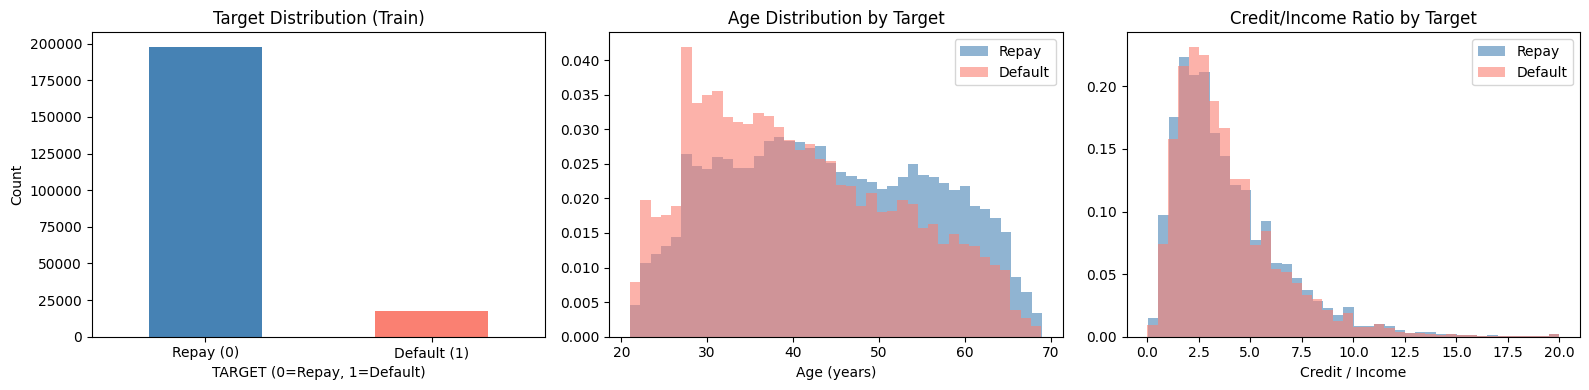

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Target Distribution (Train)')
axes[0].set_xlabel('TARGET (0=Repay, 1=Default)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Repay (0)', 'Default (1)'], rotation=0)

axes[1].hist(X_train.loc[y_train==0, 'AGE_YEARS'], bins=40, alpha=0.6, label='Repay', color='steelblue', density=True)
axes[1].hist(X_train.loc[y_train==1, 'AGE_YEARS'], bins=40, alpha=0.6, label='Default', color='salmon', density=True)
axes[1].set_title('Age Distribution by Target')
axes[1].set_xlabel('Age (years)')
axes[1].legend()

for label, color in [(0, 'steelblue'), (1, 'salmon')]:
    subset = X_train.loc[y_train==label, 'CREDIT_INCOME_RATIO'].clip(upper=20)
    axes[2].hist(subset, bins=40, alpha=0.6, color=color, density=True,
                 label='Repay' if label==0 else 'Default')
axes[2].set_title('Credit/Income Ratio by Target')
axes[2].set_xlabel('Credit / Income')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_data_prep.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, average_precision_score, classification_report)
import xgboost as xgb

# Baseline model
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=30
)

start_time = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)
xgb_train_time = time.time() - start_time

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(f'\nTraining time: {xgb_train_time:.1f}s')
print(f'Best iteration: {xgb_model.best_iteration}')
print(f'\nValidation Results:')
print(classification_report(y_val, y_val_pred_xgb))
print(f'AUC-PR: {average_precision_score(y_val, y_val_proba_xgb):.4f}')

[0]	validation_0-logloss:0.27498	validation_1-logloss:0.27522
[50]	validation_0-logloss:0.23997	validation_1-logloss:0.24911
[100]	validation_0-logloss:0.23253	validation_1-logloss:0.24811
[150]	validation_0-logloss:0.22629	validation_1-logloss:0.24796
[195]	validation_0-logloss:0.22084	validation_1-logloss:0.24815

Training time: 51.2s
Best iteration: 165

Validation Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.52      0.02      0.04      3724

    accuracy                           0.92     46127
   macro avg       0.72      0.51      0.50     46127
weighted avg       0.89      0.92      0.88     46127

AUC-PR: 0.2357


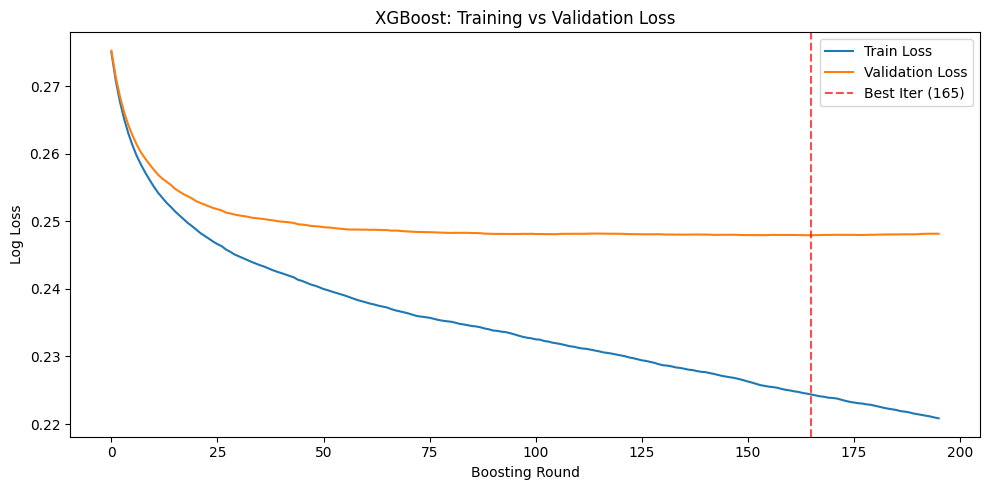

In [23]:
results = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0']['logloss'], label='Train Loss', linewidth=1.5)
ax.plot(results['validation_1']['logloss'], label='Validation Loss', linewidth=1.5)
ax.axvline(x=xgb_model.best_iteration, color='red', linestyle='--', alpha=0.7, label=f'Best Iter ({xgb_model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost: Training vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.savefig('fig_xgb_loss.png', dpi=150, bbox_inches='tight')
plt.show()

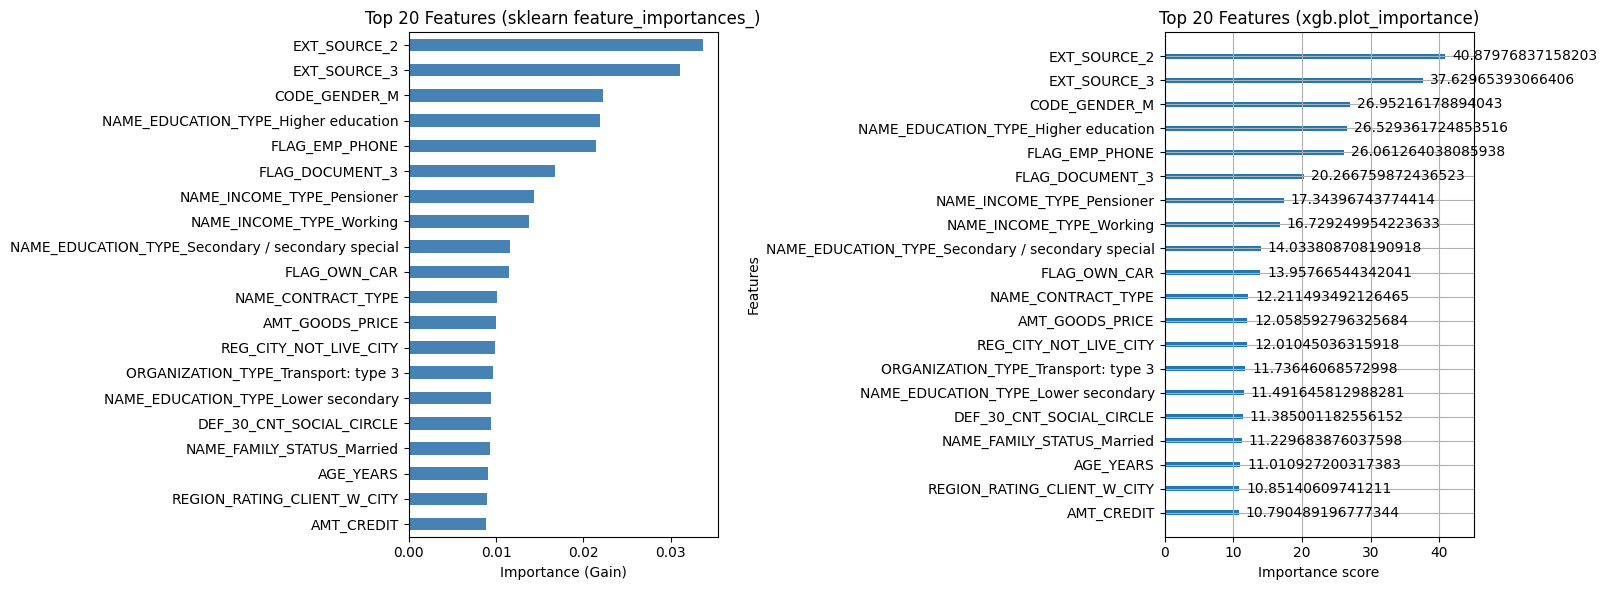

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 by gain
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)
top20.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Features (sklearn feature_importances_)')
axes[0].set_xlabel('Importance (Gain)')

# XGBoost native plot
xgb.plot_importance(xgb_model, max_num_features=20, importance_type='gain', ax=axes[1])
axes[1].set_title('Top 20 Features (xgb.plot_importance)')

plt.tight_layout()
plt.savefig('fig_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

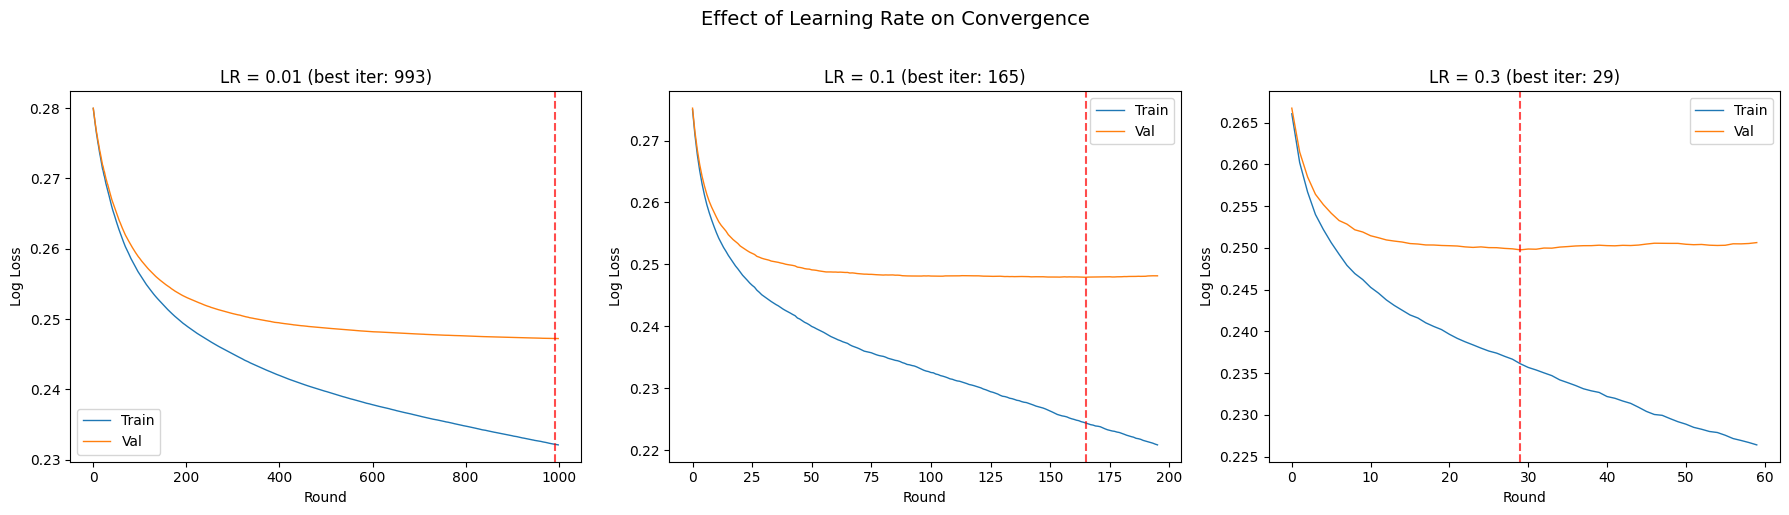

      best_iter  accuracy      f1  auc_pr
0.01      993.0    0.9196  0.0283  0.2427
0.10      165.0    0.9194  0.0403  0.2357
0.30       29.0    0.9191  0.0436  0.2292


In [25]:
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(learning_rates):
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        n_jobs=-1,
        early_stopping_rounds=30
    )
    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=0)
    res = model.evals_result()

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    lr_results[lr] = {
        'best_iter': model.best_iteration,
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'auc_pr': average_precision_score(y_val, y_proba)
    }

    axes[i].plot(res['validation_0']['logloss'], label='Train', linewidth=1)
    axes[i].plot(res['validation_1']['logloss'], label='Val', linewidth=1)
    axes[i].axvline(x=model.best_iteration, color='red', linestyle='--', alpha=0.7)
    axes[i].set_title(f'LR = {lr} (best iter: {model.best_iteration})')
    axes[i].set_xlabel('Round')
    axes[i].set_ylabel('Log Loss')
    axes[i].legend()

plt.suptitle('Effect of Learning Rate on Convergence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_xgb_lr_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame(lr_results).T.round(4))

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=RANDOM_SEED,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'\nBest params: {xgb_search.best_params_}')
print(f'Best CV F1: {xgb_search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'min_child_weight': 5, 'max_depth': 8, 'colsample_bytree': 0.9}
Best CV F1: 0.0599


In [27]:
# Train final GBDT with best params + early stopping
best_params = xgb_search.best_params_
xgb_final = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=30,
    **best_params
)

start_time = time.time()
xgb_final.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=0)
xgb_final_train_time = time.time() - start_time

y_test_pred_xgb = xgb_final.predict(X_test)
y_test_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

print(f'Final GBDT — Test Set Results:')
print(classification_report(y_test, y_test_pred_xgb))
print(f'AUC-PR: {average_precision_score(y_test, y_test_proba_xgb):.4f}')
print(f'Training time: {xgb_final_train_time:.1f}s')

Final GBDT — Test Set Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.53      0.02      0.04      3724

    accuracy                           0.92     46127
   macro avg       0.72      0.51      0.50     46127
weighted avg       0.89      0.92      0.88     46127

AUC-PR: 0.2330
Training time: 39.2s


In [28]:
from sklearn.neural_network import MLPClassifier

# Test different architectures
architectures = {
    '(64,)': (64,),
    '(128, 64)': (128, 64),
    '(256, 128, 64)': (256, 128, 64)
}

arch_results = {}
arch_loss_curves = {}

for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        batch_size=256
    )
    start_time = time.time()
    mlp.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    y_pred = mlp.predict(X_val_scaled)
    y_proba = mlp.predict_proba(X_val_scaled)[:, 1]

    arch_results[name] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'auc_pr': average_precision_score(y_val, y_proba),
        'train_time': round(train_time, 1),
        'n_iter': mlp.n_iter_
    }
    arch_loss_curves[name] = mlp.loss_curve_

print(pd.DataFrame(arch_results).T.round(4))

                accuracy      f1  auc_pr  train_time  n_iter
(64,)             0.9192  0.0246  0.2125        41.1    18.0
(128, 64)         0.9193  0.0127  0.2113        78.2    19.0
(256, 128, 64)    0.9194  0.0075  0.2139       157.2    17.0


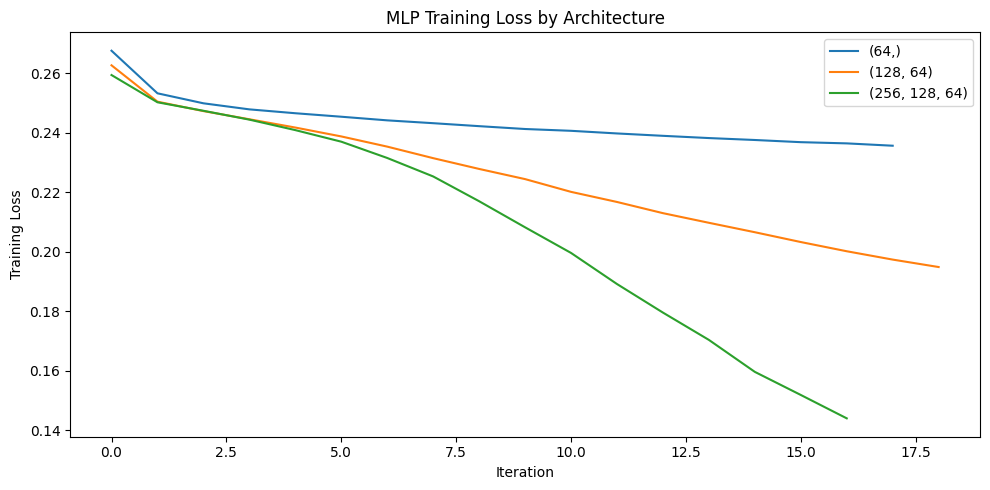

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, curve in arch_loss_curves.items():
    ax.plot(curve, label=name, linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('MLP Training Loss by Architecture')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_loss_arch.png', dpi=150, bbox_inches='tight')
plt.show()

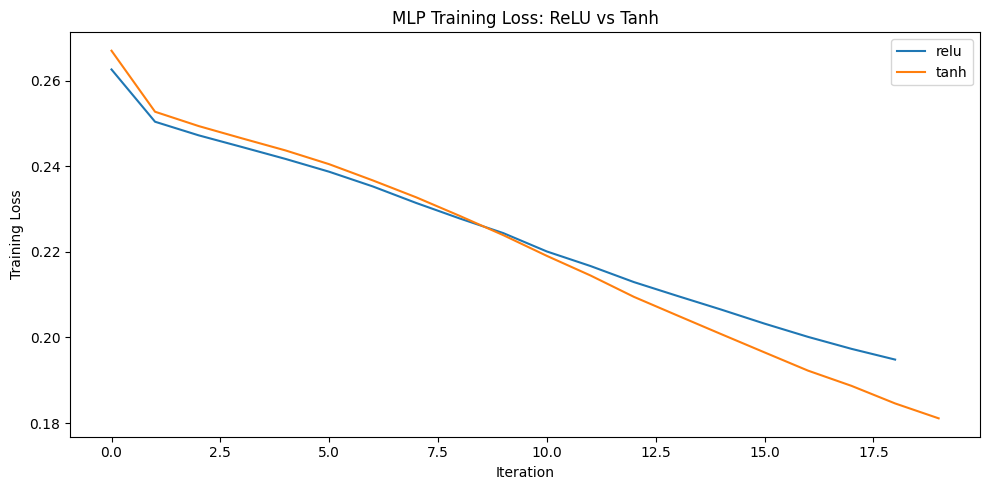

      accuracy      f1  auc_pr  n_iter
relu    0.9193  0.0127  0.2113    19.0
tanh    0.9193  0.0226  0.2078    20.0


In [30]:
activations = ['relu', 'tanh']
act_results = {}
act_loss_curves = {}

for act in activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        solver='adam',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        batch_size=256
    )
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_val_scaled)
    y_proba = mlp.predict_proba(X_val_scaled)[:, 1]

    act_results[act] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'auc_pr': average_precision_score(y_val, y_proba),
        'n_iter': mlp.n_iter_
    }
    act_loss_curves[act] = mlp.loss_curve_

fig, ax = plt.subplots(figsize=(10, 5))
for act, curve in act_loss_curves.items():
    ax.plot(curve, label=act, linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('MLP Training Loss: ReLU vs Tanh')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_activation.png', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame(act_results).T.round(4))

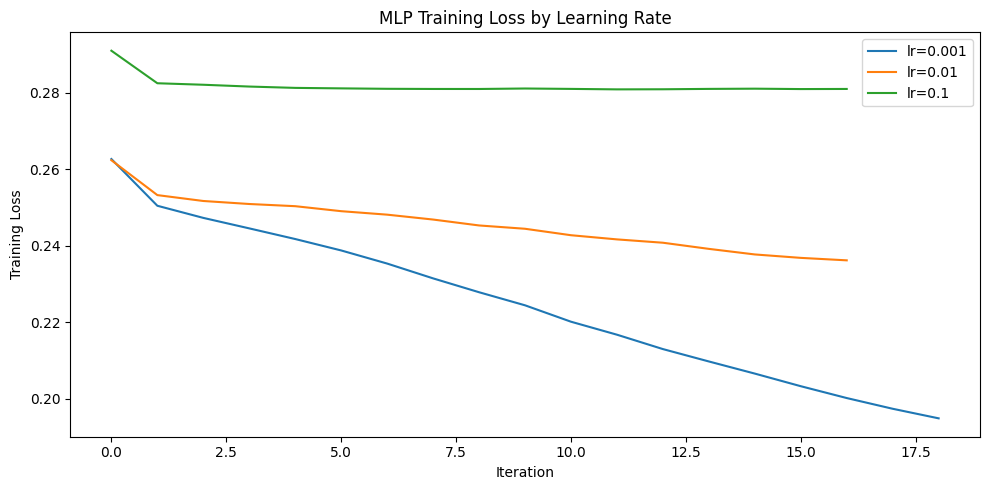

       accuracy      f1  auc_pr  n_iter
0.001    0.9193  0.0127  0.2113    19.0
0.010    0.9192  0.0005  0.2130    17.0
0.100    0.9193  0.0000  0.0807    17.0


In [31]:
lr_inits = [0.001, 0.01, 0.1]
mlp_lr_results = {}
mlp_lr_curves = {}

for lr in lr_inits:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        max_iter=300,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        batch_size=256
    )
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_val_scaled)
    y_proba = mlp.predict_proba(X_val_scaled)[:, 1]

    mlp_lr_results[lr] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'auc_pr': average_precision_score(y_val, y_proba),
        'n_iter': mlp.n_iter_
    }
    mlp_lr_curves[lr] = mlp.loss_curve_

fig, ax = plt.subplots(figsize=(10, 5))
for lr, curve in mlp_lr_curves.items():
    ax.plot(curve, label=f'lr={lr}', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('MLP Training Loss by Learning Rate')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame(mlp_lr_results).T.round(4))

In [32]:
# Train final MLP with best observed settings
mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    batch_size=256
)

start_time = time.time()
mlp_final.fit(X_train_scaled, y_train)
mlp_final_train_time = time.time() - start_time

y_test_pred_mlp = mlp_final.predict(X_test_scaled)
y_test_proba_mlp = mlp_final.predict_proba(X_test_scaled)[:, 1]

print(f'Final MLP — Test Set Results:')
print(classification_report(y_test, y_test_pred_mlp))
print(f'AUC-PR: {average_precision_score(y_test, y_test_proba_mlp):.4f}')
print(f'Training time: {mlp_final_train_time:.1f}s')

Final MLP — Test Set Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.43      0.01      0.01      3724

    accuracy                           0.92     46127
   macro avg       0.67      0.50      0.48     46127
weighted avg       0.88      0.92      0.88     46127

AUC-PR: 0.2101
Training time: 100.7s


In [33]:
from sklearn.metrics import precision_recall_curve

metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-PR', 'Training Time (s)'],
    'GBDT (XGBoost)': [
        accuracy_score(y_test, y_test_pred_xgb),
        precision_score(y_test, y_test_pred_xgb),
        recall_score(y_test, y_test_pred_xgb),
        f1_score(y_test, y_test_pred_xgb),
        average_precision_score(y_test, y_test_proba_xgb),
        round(xgb_final_train_time, 1)
    ],
    'MLP': [
        accuracy_score(y_test, y_test_pred_mlp),
        precision_score(y_test, y_test_pred_mlp),
        recall_score(y_test, y_test_pred_mlp),
        f1_score(y_test, y_test_pred_mlp),
        average_precision_score(y_test, y_test_proba_mlp),
        round(mlp_final_train_time, 1)
    ]
}

comparison_df = pd.DataFrame(metrics)
comparison_df.iloc[:5, 1:] = comparison_df.iloc[:5, 1:].round(4)
print(comparison_df.to_string(index=False))

           Metric  GBDT (XGBoost)      MLP
         Accuracy          0.9195   0.9191
        Precision          0.5287   0.4255
           Recall          0.0223   0.0054
         F1-Score          0.0428   0.0106
           AUC-PR          0.2330   0.2101
Training Time (s)         39.2000 100.7000


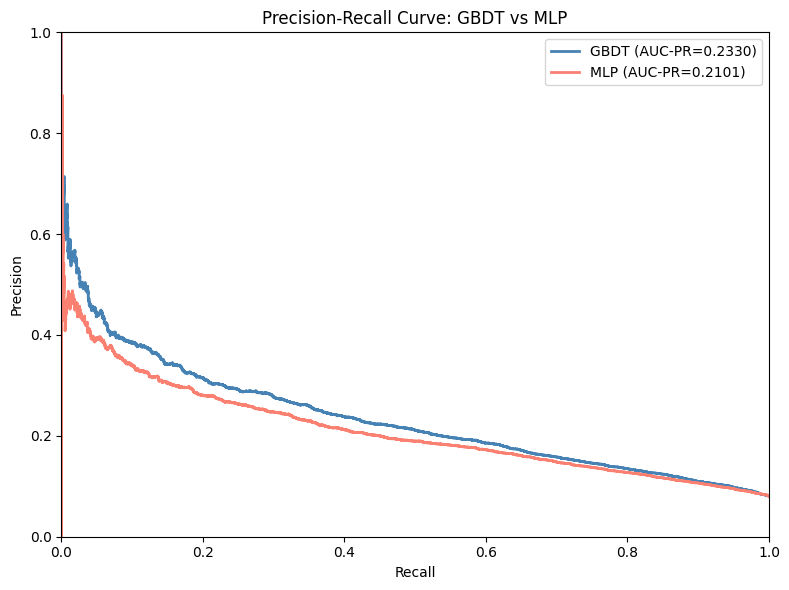

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in [('GBDT', y_test_proba_xgb, 'steelblue'), ('MLP', y_test_proba_mlp, 'salmon')]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(recall, precision, label=f'{name} (AUC-PR={ap:.4f})', color=color, linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve: GBDT vs MLP')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('fig_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

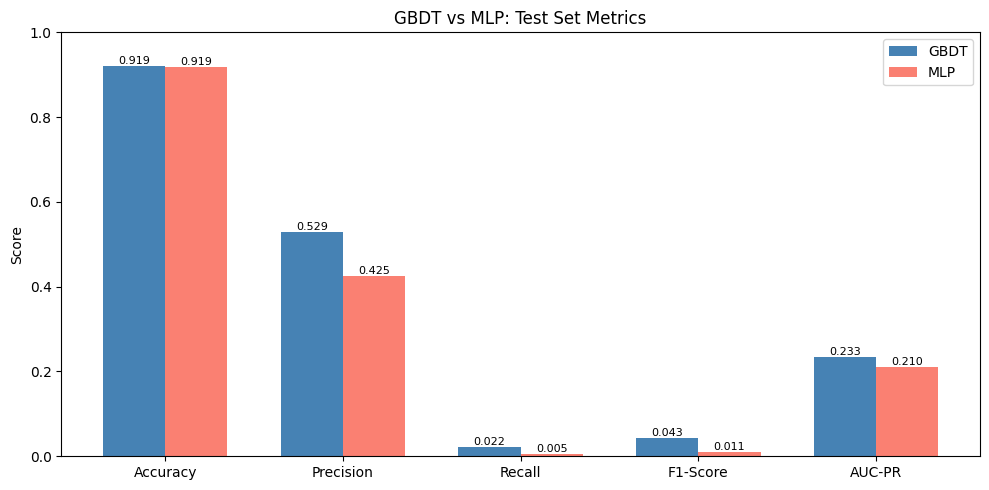

In [35]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-PR']
gbdt_vals = [float(comparison_df[comparison_df['Metric']==m]['GBDT (XGBoost)'].values[0]) for m in metrics_to_plot]
mlp_vals = [float(comparison_df[comparison_df['Metric']==m]['MLP'].values[0]) for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, gbdt_vals, width, label='GBDT', color='steelblue')
bars2 = ax.bar(x + width/2, mlp_vals, width, label='MLP', color='salmon')

ax.set_ylabel('Score')
ax.set_title('GBDT vs MLP: Test Set Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim([0, 1])
ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig('fig_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()